# 04 - Grad-CAM: Explainability


In this notebook we use Grad-CAM (Gradient-weighted Class Activation Mapping)
to visualize which regions of a chest X-ray image the model focuses on when
making a prediction. This is covered in Chollet (2025, Chapter 10).

Grad-CAM works by computing the gradient of the target class with respect to
the last convolutional layer, weighting each channel by its importance, and
producing a heatmap that highlights the most relevant regions.

Why explainability matters in medical imaging:  

Deep learning models are often referred to as "black boxes" - they make
predictions without explaining why. In a clinical setting, radiologists cannot
blindly trust a model's output. Grad-CAM provides visual explanations that
can support clinicians in understanding and validating the model's predictions
(Selvaraju et al., 2019).

Limitation:  
There is no mathematical formula for interpretability. The
evaluation of Grad-CAM heatmaps is inherently subjective. Ideally, we would
have clinical experts evaluate whether the highlighted regions are anatomically
relevant. Within the scope of this project, we instead visually inspect whether
the model focuses on clinically plausible regions for each condition.

## 1. Import libraries

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import kagglehub
import tensorflow as tf
import keras
from keras import layers
import warnings
warnings.filterwarnings("ignore")

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2


## 2. Load data and model

We load the best performing model from our experiments.
We use the Baseline CNN since it achieved the highest AUC (0.865).

In [15]:
# Download dataset
path = kagglehub.dataset_download("ashery/chexpert")

# Load validation data
valid_df = pd.read_csv(os.path.join(path, "valid.csv"))

# The 5 clinically most important conditions
LABELS = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion']

# Use only frontal images
valid_df = valid_df[valid_df['Frontal/Lateral'] == 'Frontal']

print(f"Validation images: {len(valid_df)}")

# Load best model
MODEL_PATH = '../results/baseline_cnn_best.keras'
model = keras.models.load_model(MODEL_PATH)
print("Model loaded successfully!")
model.summary()

Validation images: 202
Model loaded successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,366,481 (5.21 MB)

 Trainable params: 455,493 (1.74 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 910,988 (3.48 MB)

## 3. Implement Grad-CAM

Following Chollet (2025, Chapter 10) and Selvaraju et al. (2019), Grad-CAM
consists of:

1. Getting the output of the last convolutional layer
2. Computing the gradient of the target class with respect to that output
3. Pooling the gradients to get channel importance weights
4. Weighting the feature map channels by their importance
5. Taking the mean across channels to get the heatmap

In [16]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that outputs the last conv layer and the final predictions
    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Gradient of the target class with respect to last conv layer output
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Pool the gradients over the spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the feature maps by the pooled gradients
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize to [0, 1]
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def superimpose_heatmap(img, heatmap, alpha=0.4):
    # Resize heatmap to image size
    heatmap_resized = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_resized]
    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)

    # Superimpose heatmap on original image
    superimposed = jet_heatmap * alpha + img
    superimposed = keras.utils.array_to_img(superimposed)
    return superimposed


def load_and_preprocess(img_path, target_size=(224, 224)):
    img = keras.utils.load_img(img_path, target_size=target_size)
    img_array = keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    return img_array


print("Grad-CAM functions defined!")

Grad-CAM functions defined!


## 4. Find the last convolutional layer

For Grad-CAM we need the name of the last convolutional layer in our model.

In [17]:
# Find the last Conv2D layer
for layer in reversed(model.layers):
    if isinstance(layer, layers.Conv2D):
        last_conv_layer_name = layer.name
        print(f"Last Conv2D layer: {last_conv_layer_name}")
        break

Last Conv2D layer: conv2d_3


## 5. Visualize Grad-CAM heatmaps

We visualize Grad-CAM heatmaps for each of the 5 conditions. For each
condition we select an image from the validation set that has a positive
label, and show:
- The original X-ray image
- The Grad-CAM heatmap
- The superimposed image

We then assess whether the model focuses on clinically relevant regions.
Expected anatomical regions:
- Atelectasis → lungs (collapsed lung tissue)
- Cardiomegaly → heart (enlarged heart)
- Consolidation → lungs (fluid in lung tissue)
- Edema → lungs (fluid buildup)
- Pleural Effusion → lower lungs / pleural space

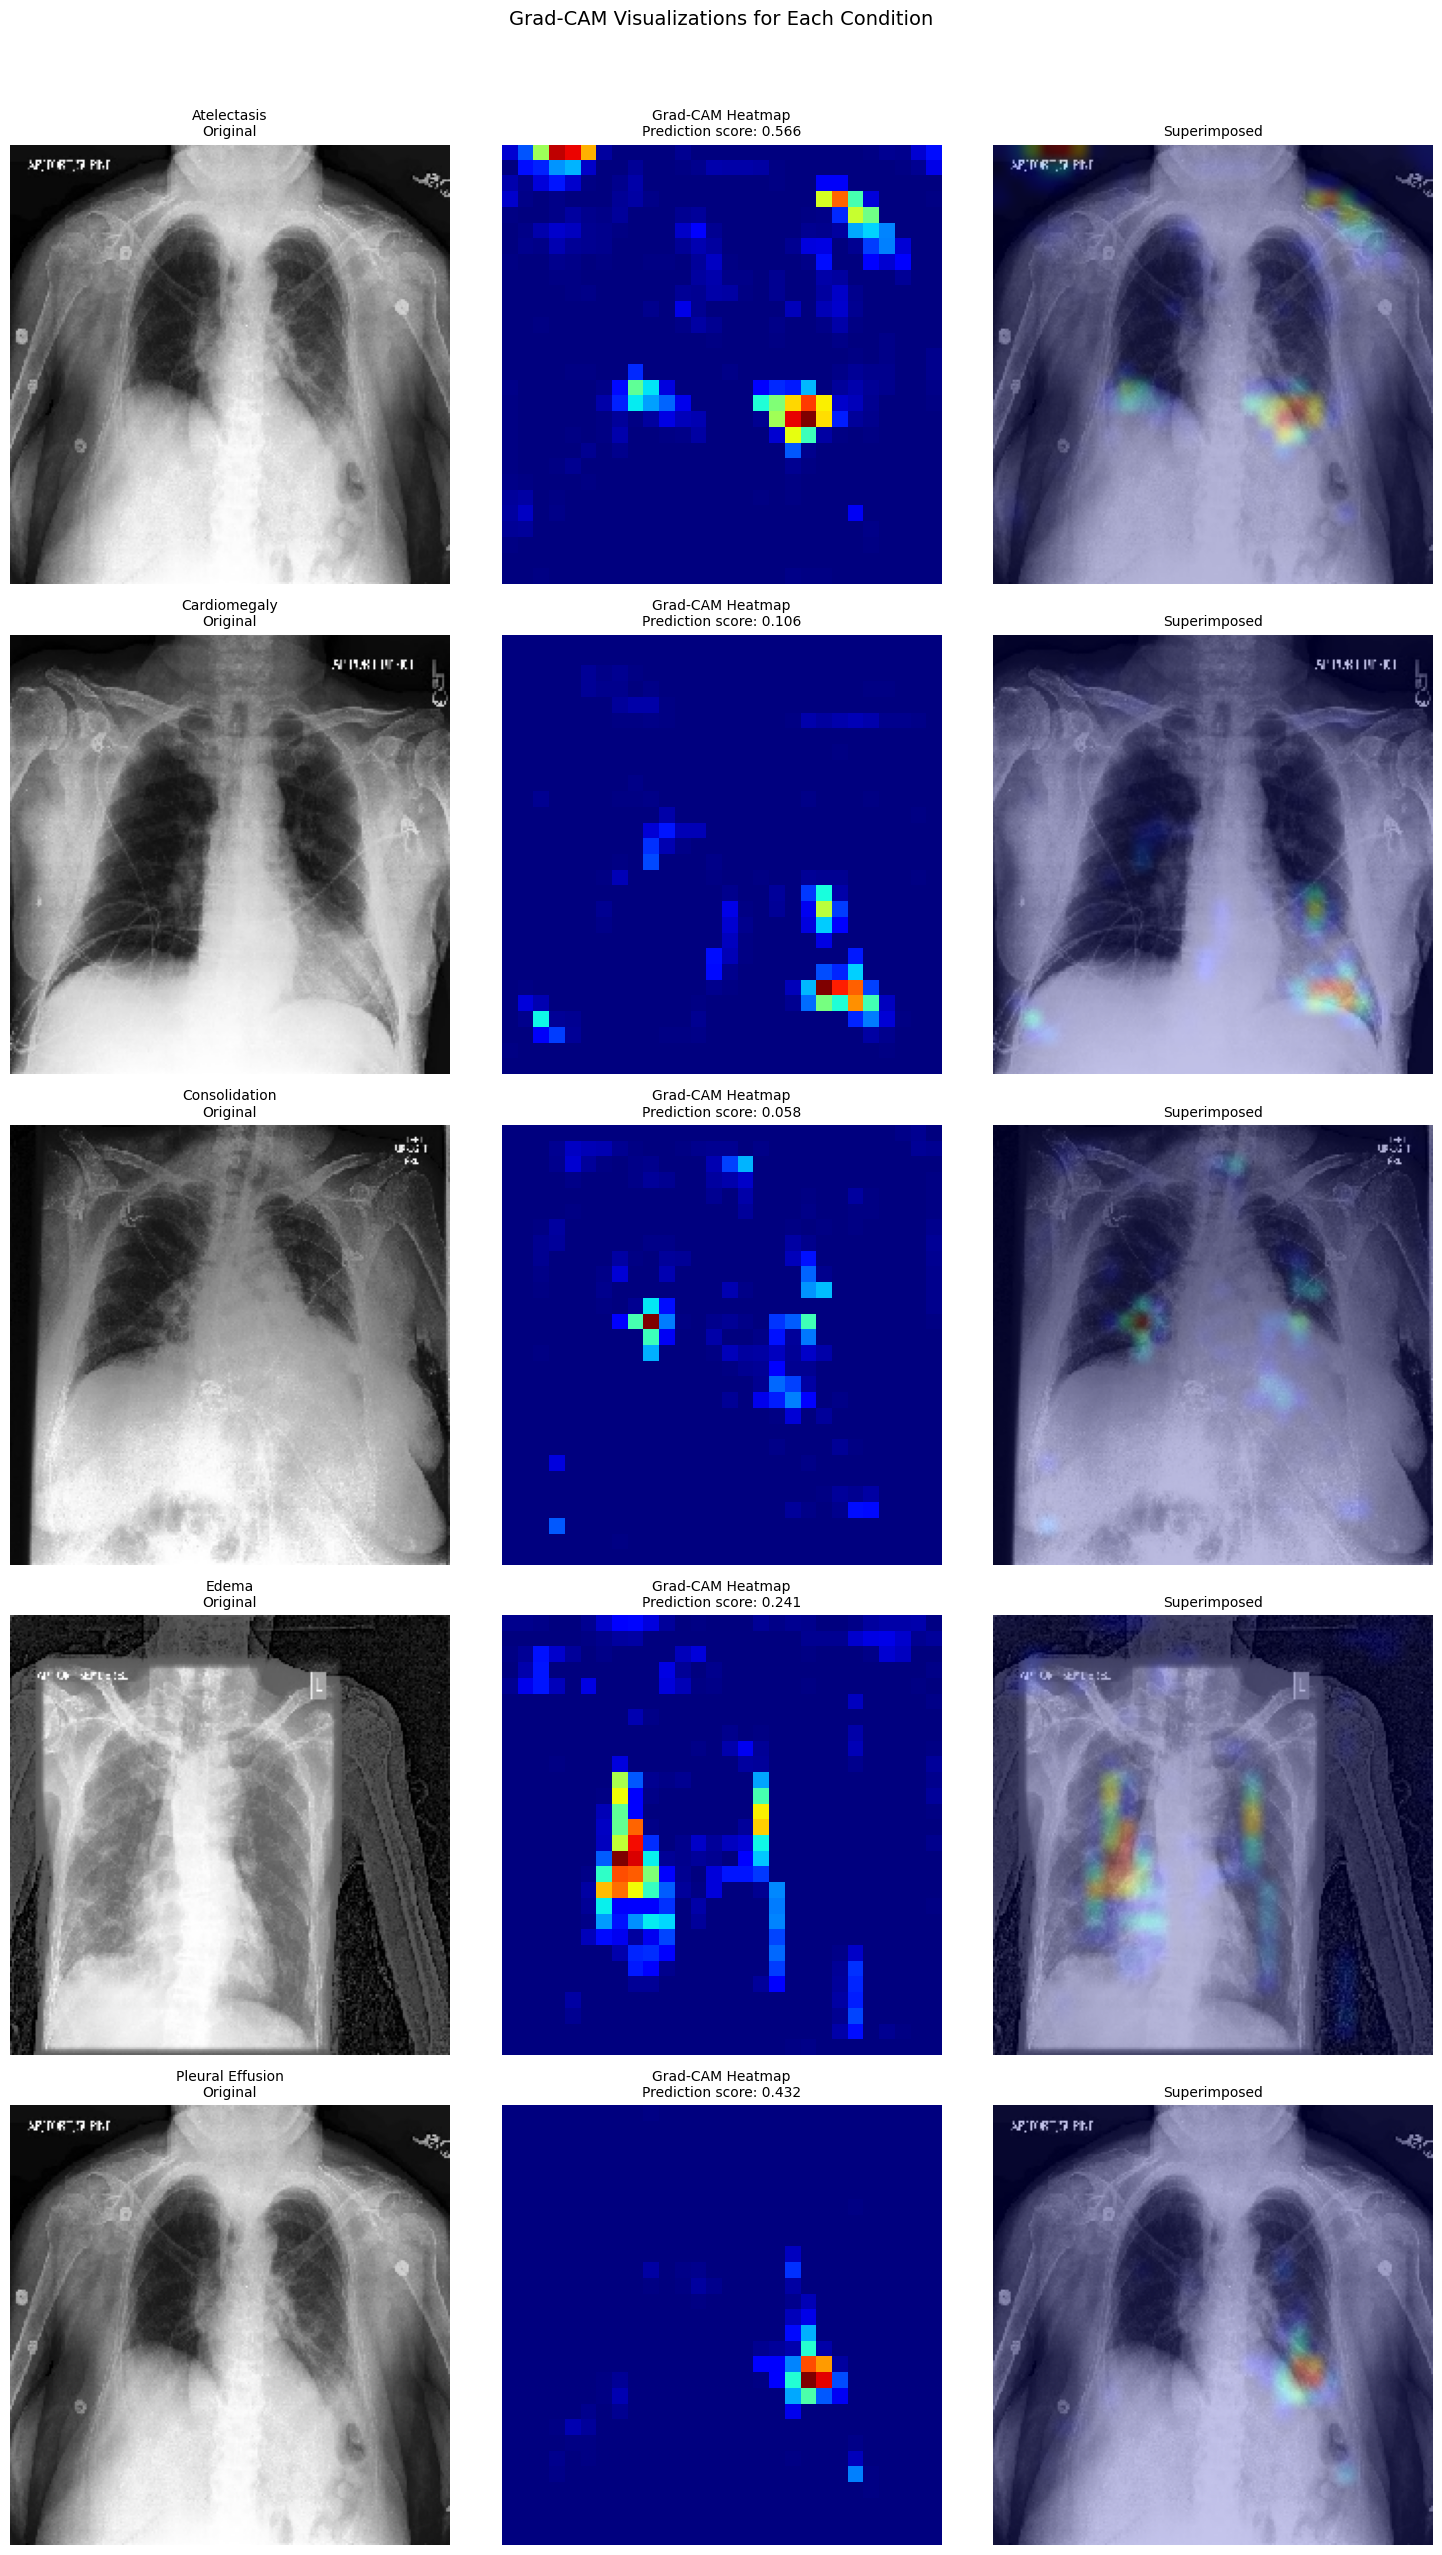

In [18]:
fig, axes = plt.subplots(len(LABELS), 3, figsize=(15, 5 * len(LABELS)))

for idx, label in enumerate(LABELS):
    # Find a positive sample for this condition
    positive_samples = valid_df[valid_df[label] == 1.0]
    if len(positive_samples) == 0:
        continue

    # Take first positive sample
    row = positive_samples.iloc[0]
    relative_path = row['Path'].replace("CheXpert-v1.0-small/", "")
    img_path = os.path.join(path, relative_path)

    # Load and preprocess image
    img_array = load_and_preprocess(img_path)
    img_array_expanded = np.expand_dims(img_array, axis=0)

    # Get prediction
    pred = model.predict(img_array_expanded, verbose=0)
    pred_score = pred[0][LABELS.index(label)]

    # Generate Grad-CAM heatmap
    heatmap = make_gradcam_heatmap(
        img_array_expanded,
        model,
        last_conv_layer_name,
        pred_index=LABELS.index(label)
    )

    # Superimpose heatmap
    img_display = np.uint8(img_array * 255)
    superimposed = superimpose_heatmap(img_display, heatmap)

    # Plot
    axes[idx, 0].imshow(img_display, cmap='gray')
    axes[idx, 0].set_title(f'{label}\nOriginal', fontsize=10)
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(heatmap, cmap='jet')
    axes[idx, 1].set_title(f'Grad-CAM Heatmap\nPrediction score: {pred_score:.3f}', fontsize=10)
    axes[idx, 1].axis('off')

    axes[idx, 2].imshow(superimposed)
    axes[idx, 2].set_title('Superimposed', fontsize=10)
    axes[idx, 2].axis('off')

plt.suptitle('Grad-CAM Visualizations for Each Condition', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/gradcam_all_conditions.png')
plt.show()

## 6. Compare correct vs incorrect predictions

We compare Grad-CAM heatmaps for correct and incorrect predictions to
investigate whether the model focuses on different regions when it fails.
This gives insight into potential failure modes of the model.

In [19]:
# Focus on Edema since it had the highest AUC (0.922)
target_label = 'Edema'
label_idx = LABELS.index(target_label)

# Get all predictions on validation set
all_preds = []
all_true = []
all_paths = []

for _, row in valid_df.iterrows():
    relative_path = row['Path'].replace("CheXpert-v1.0-small/", "")
    img_path = os.path.join(path, relative_path)
    img_array = load_and_preprocess(img_path)
    img_array_expanded = np.expand_dims(img_array, axis=0)
    pred = model.predict(img_array_expanded, verbose=0)
    all_preds.append(pred[0][label_idx])
    all_true.append(row[target_label] if not pd.isna(row[target_label]) else 0)
    all_paths.append(img_path)

all_preds = np.array(all_preds)
all_true = np.array(all_true)

# Find correct and incorrect predictions (threshold 0.5)
threshold = 0.5
predicted_positive = all_preds >= threshold
true_positive_mask = (all_true == 1) & predicted_positive   # correct
false_negative_mask = (all_true == 1) & ~predicted_positive  # missed

print(f"True positives: {true_positive_mask.sum()}")
print(f"False negatives: {false_negative_mask.sum()}")

True positives: 37
False negatives: 5


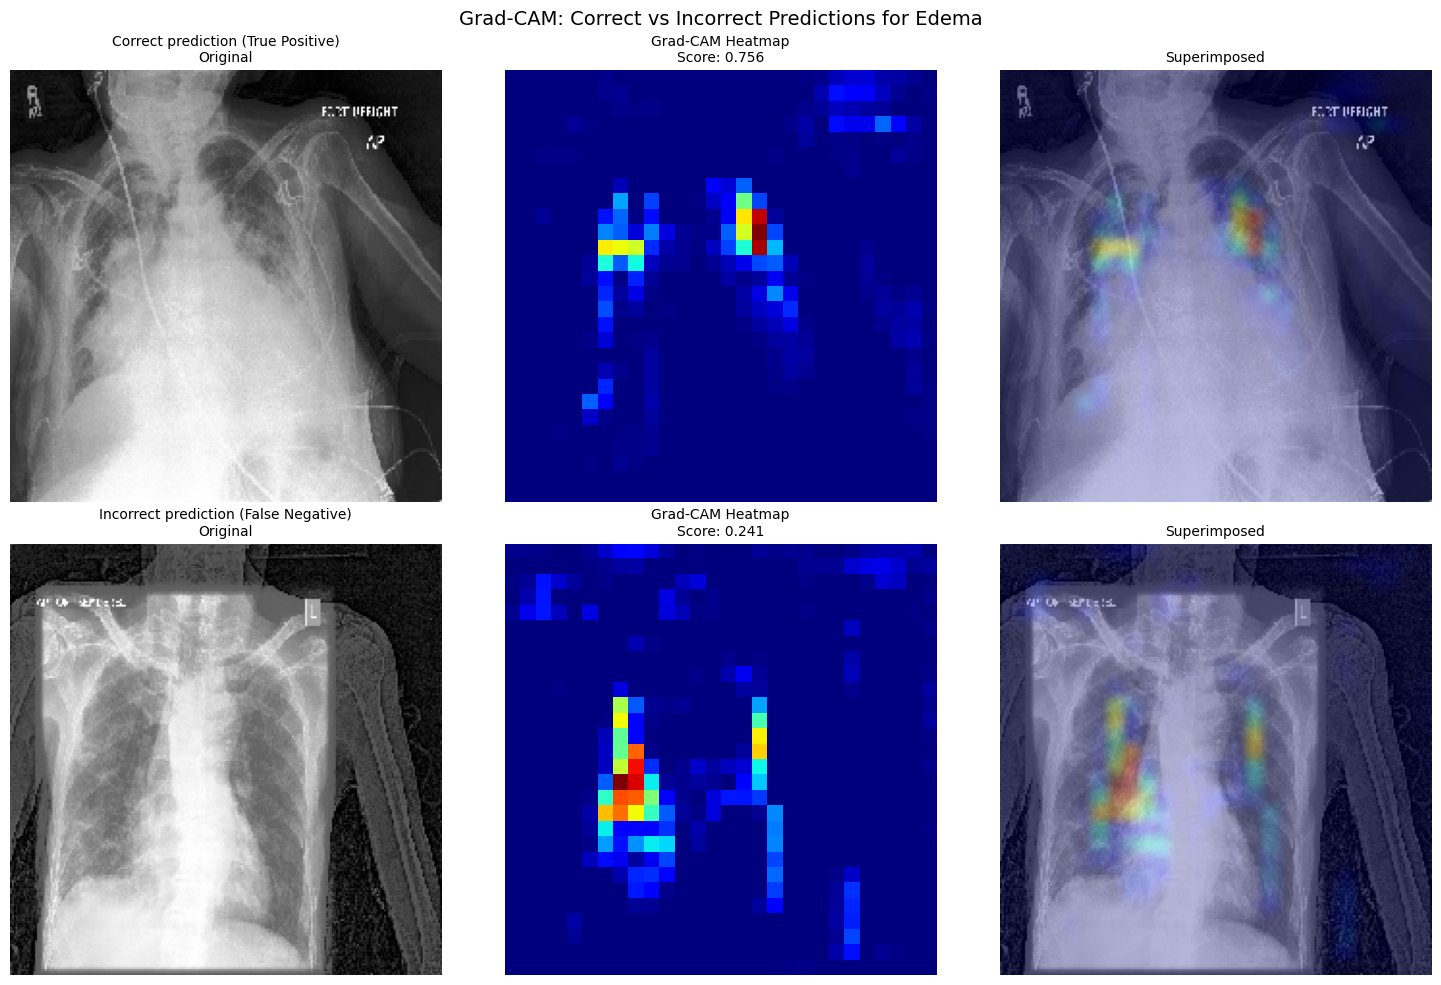

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row_idx, (mask, title) in enumerate([
    (true_positive_mask, 'Correct prediction (True Positive)'),
    (false_negative_mask, 'Incorrect prediction (False Negative)')
]):
    indices = np.where(mask)[0]
    if len(indices) == 0:
        continue

    img_path = all_paths[indices[0]]
    img_array = load_and_preprocess(img_path)
    img_array_expanded = np.expand_dims(img_array, axis=0)
    pred_score = all_preds[indices[0]]

    heatmap = make_gradcam_heatmap(
        img_array_expanded,
        model,
        last_conv_layer_name,
        pred_index=label_idx
    )

    img_display = np.uint8(img_array * 255)
    superimposed = superimpose_heatmap(img_display, heatmap)

    axes[row_idx, 0].imshow(img_display, cmap='gray')
    axes[row_idx, 0].set_title(f'{title}\nOriginal', fontsize=10)
    axes[row_idx, 0].axis('off')

    axes[row_idx, 1].imshow(heatmap, cmap='jet')
    axes[row_idx, 1].set_title(f'Grad-CAM Heatmap\nScore: {pred_score:.3f}', fontsize=10)
    axes[row_idx, 1].axis('off')

    axes[row_idx, 2].imshow(superimposed)
    axes[row_idx, 2].set_title('Superimposed', fontsize=10)
    axes[row_idx, 2].axis('off')

plt.suptitle(f'Grad-CAM: Correct vs Incorrect Predictions for {target_label}', fontsize=14)
plt.tight_layout()
plt.savefig('../results/figures/gradcam_correct_vs_incorrect.png')
plt.show()

## 7. Discussion

The Grad-CAM heatmaps provide visual insight into the model's decision-making
process. Key observations:

- Pleural Effusion (score: 0.432): The model focuses on the lower lung 
  region, which is clinically consistent with where pleural effusion typically 
  appears. 
- Atelectasis (score: 0.566): The model focuses on the upper lung fields, 
  which is partially clinically relevant. 
- Edema (score: 0.241): The model shows some activation in the lung fields, 
  though the low prediction score suggests uncertainty. 
- Cardiomegaly (score: 0.106): The model focuses on the lower right region 
  rather than the cardiac silhouette in the center, this is clinically 
  inconsistent and aligns with the low AUC (0.796) for this condition. 
- Consolidation (score: 0.058): Very low prediction score with scattered 
  activation. the model appears uncertain and does not focus on a specific 
  clinically relevant region. 

Correct vs Incorrect predictions for Edema:  
The True Positive (score: 0.756) shows activation in the upper lung fields,
while the False Negative (score: 0.241) shows more central activation,
suggesting the model focuses on different regions when it fails, which may
indicate it misses subtle Edema patterns in certain presentations.

Limitation of this evaluation:  
Comparing correct vs incorrect predictions does not constitute a formal metric 
for interpretability. Ideally, board-certified radiologists would evaluate 
whether the highlighted regions are anatomically relevant, as suggested by the 
project's original scope. Within the constraints of this project, this visual 
inspection serves as a qualitative assessment of model interpretability.

## References
- Chollet, F. (2025). *Deep Learning with Python*, 3rd edition. Manning Publications.
- Selvaraju, R.R. et al. (2019). Grad-CAM: Visual Explanations from Deep Networks via Gradient-Based Localization. *ICCV*. https://arxiv.org/abs/1610.02391
- Irvin, J. et al. (2019). CheXpert: A Large Chest Radiograph Dataset with Uncertainty Labels and Expert Comparison. *AAAI*. https://arxiv.org/abs/1901.07031